# GRIT Mekong Mega Reservoirs — Lake Analysis

Explore the GRIT river reach data to count how many unique lakes (reservoirs) are represented.

In [ ]:
import geopandas as gpd
import pandas as pd

# Load GRIT reach data
reaches_path = r"E:\Project_2025_2026\Smart_hs\raw_data\grit\GRIT_mekong_mega_reservoirs\reaches\gritv06_reaches_mekong_basin_with_pld_lakes.shp"
reaches = gpd.read_file(reaches_path)

print(f"Total reaches: {len(reaches)}")
print(f"\nColumns: {list(reaches.columns)}")
reaches.head()

Total reaches: 117774

Columns: ['fid', 'cat', 'segment_id', 'global_id', 'catchment_', 'upstream_n', 'downstream', 'upstream_l', 'downstre_1', 'grwl_overl', 'grwl_value', 'grwl_width', 'grwl_wid_1', 'length', 'sinuosity', 'azimuth', 'domain', 'lake_id', 'geometry']


,fid,cat,segment_id,global_id,catchment_,upstream_n,downstream,upstream_l,downstre_1,grwl_overl,grwl_value,grwl_width,grwl_wid_1,length,sinuosity,azimuth,domain,lake_id,geometry
0,330130650.0,130650.0,330051895.0,330130650.0,330000005.0,330212796.0,330212797.0,330130649,330130651,0.0,0.0,30.0,0.0,970.156380,1.070462,43.375725,MEKO,4.420000e+09,"LINESTRING (104.4971 11.06159, 104.49741 11.06..."
1,330130651.0,130651.0,330051895.0,330130651.0,330000005.0,330212797.0,330212798.0,330130650,330130652,0.0,0.0,30.0,0.0,946.613622,1.024577,47.703843,MEKO,4.420000e+09,"LINESTRING (104.50453 11.06677, 104.51037 11.0..."
2,330130711.0,130711.0,330051903.0,330130711.0,330000005.0,330212850.0,330212851.0,330130710,330130712,0.0,0.0,30.0,0.0,904.234991,1.004066,1.908997,MEKO,4.420000e+09,"LINESTRING (104.80953 10.95186, 104.81065 10.9..."
3,330130712.0,130712.0,330051903.0,330130712.0,330000005.0,330212851.0,330212852.0,330130711,330130713,0.0,0.0,30.0,0.0,912.499567,1.000000,0.000000,MEKO,4.420000e+09,"LINESTRING (104.81102 10.95893, 104.81221 10.9..."
4,330130713.0,130713.0,330051903.0,330130713.0,330000005.0,330212852.0,330212853.0,330130712,330130714,0.0,0.0,30.0,0.0,864.693576,1.024447,334.683519,MEKO,4.420000e+09,"LINESTRING (104.81221 10.9661, 104.81198 10.96..."


## Count unique lakes in the GRIT reach data

In [ ]:
# Identify the lake ID column (adjust name if different after inspecting columns above)
lake_col = [c for c in reaches.columns if 'lake' in c.lower()][0]
print(f"Lake ID column: '{lake_col}'")

# Exclude reaches with no associated lake (null / 0 / -1 depending on encoding)
with_lake = reaches[reaches[lake_col].notna() & (reaches[lake_col] != 0) & (reaches[lake_col] != -1)]

n_unique_lakes = with_lake[lake_col].nunique()
n_reaches_with_lake = len(with_lake)

print(f"\nUnique lakes (reservoirs) in GRIT reach data: {n_unique_lakes}")
print(f"Reaches associated with a lake: {n_reaches_with_lake} / {len(reaches)}")

Lake ID column: 'lake_id'

Unique lakes (reservoirs) in GRIT reach data: 1508
Reaches associated with a lake: 8126 / 117774


In [ ]:
# Reaches per lake — how many reaches cover each reservoir
reaches_per_lake = with_lake.groupby(lake_col).size().rename("reach_count")
print("Distribution of reaches per lake:")
print(reaches_per_lake.describe().round(1))
print()
print("Top 10 lakes by reach count:")
reaches_per_lake.sort_values(ascending=False).head(10)

Distribution of reaches per lake:
count    1508.0
mean        5.4
std        27.3
min         1.0
25%         1.0
50%         1.0
75%         2.0
max       569.0
Name: reach_count, dtype: float64

Top 10 lakes by reach count:


lake_id
4.420183e+09    569
4.420024e+09    566
4.420182e+09    326
4.420183e+09    321
4.420191e+09    170
4.420190e+09    162
4.420190e+09    144
4.420190e+09    137
4.420137e+09    130
4.420157e+09    129
Name: reach_count, dtype: int64

## Prior lake database — info for lakes present in GRIT reaches

In [ ]:
# Load SWOT prior lake database
pld_path = r"E:\Project_2025_2026\Smart_hs\raw_data\grit\GRIT_mekong_mega_reservoirs\prior_lake_database\swot_prior_lake_database_mekong_overlap_with_grit.shp"
pld = gpd.read_file(pld_path)

print(f"Total lakes in prior lake database: {len(pld)}")
print(f"\nColumns: {list(pld.columns)}")
pld.head()

Total lakes in prior lake database: 1611

Columns: ['lake_id', 'basin_id', 'names', 'res_id', 'reach_id_l', 'lon', 'lat', 'poly_area', 'poly_perim', 'ref_area', 'ref_area_u', 'ref_wse', 'ref_wse_u', 'date_t0', 'ds_t0', 'storage', 'ice_clim_f', 'ice_clim_1', 'nb_ice_cli', 'pass_full_', 'nb_pass_fu', 'pass_part_', 'nb_pass_pa', 'pass_ful_1', 'nb_pass__1', 'pass_par_1', 'nb_pass__2', 'cycle_flag', 'cycle_fl_1', 'min_dist_l', 'min_dist_1', 'min_dist_r', 'min_dist_2', 'update_ver', 'updated_it', 'sources', 'geometry']


,lake_id,basin_id,names,res_id,reach_id_l,lon,lat,poly_area,poly_perim,ref_area,...,cycle_flag,cycle_fl_1,min_dist_l,min_dist_1,min_dist_r,min_dist_2,update_ver,updated_it,sources,geometry
0,4.420000e+09,442,None,NaN,None,104.507131,11.067095,0.9495000072799404,9.599999648142186,0.9495,...,0,3,60,4.420000e+09,40757,4.421000e+10,None,None,Circa2015,"POLYGON ((104.50171 11.06141, 104.50143 11.061..."
1,4.420000e+09,442,BOENG O TOM,NaN,None,104.814136,10.965144,0.8883000327115692,7.979999217999243,0.8883,...,0,3,30,4.420000e+09,25209,4.421000e+10,None,None,Circa2015,"POLYGON ((104.8116 10.95812, 104.81077 10.9581..."
2,4.420000e+09,442,BOENG O TOM,NaN,None,104.807702,10.941992,1.647900033476723,13.3800001672245,1.6479,...,0,3,30,4.420000e+09,25435,4.421000e+10,None,None,Circa2015,"POLYGON ((104.79761 10.92474, 104.79734 10.924..."
3,4.420000e+09,442,None,NaN,None,104.791612,11.072122,4.610705055364772,58.43414246702497,4.6107,...,0,3,1290,4.420000e+09,24001,4.421000e+10,None,None,Circa2015;digitize,"POLYGON ((104.78982 11.08129, 104.78982 11.081..."
4,4.420000e+09,442,None,NaN,None,104.805429,11.150053,0.2600999935959535,5.88000015681145,0.2601,...,0,3,30,4.420000e+09,22155,4.421000e+10,None,None,Circa2015,"POLYGON ((104.80351 11.14614, 104.80268 11.146..."


In [ ]:
# Get the unique lake IDs found in the GRIT reach data
grit_lake_ids = with_lake[lake_col].unique()

# Identify the lake ID column in the PLD (adjust if auto-detection misses)
pld_id_col = [c for c in pld.columns if 'lake' in c.lower() or 'id' in c.lower()][0]
print(f"PLD lake ID column: '{pld_id_col}'")

# Filter PLD to only lakes present in GRIT reaches
pld_grit = pld[pld[pld_id_col].isin(grit_lake_ids)].copy()

print(f"\nLakes in PLD that match GRIT reach data: {len(pld_grit)} / {n_unique_lakes} unique lake IDs in reaches")
pld_grit

PLD lake ID column: 'lake_id'

Lakes in PLD that match GRIT reach data: 1508 / 1508 unique lake IDs in reaches


,lake_id,basin_id,names,res_id,reach_id_l,lon,lat,poly_area,poly_perim,ref_area,...,cycle_flag,cycle_fl_1,min_dist_l,min_dist_1,min_dist_r,min_dist_2,update_ver,updated_it,sources,geometry
0,4.420000e+09,442,None,NaN,None,104.507131,11.067095,0.9495000072799404,9.599999648142186,0.949500,...,0,3,60,4.420000e+09,40757,4.421000e+10,None,None,Circa2015,"POLYGON ((104.50171 11.06141, 104.50143 11.061..."
1,4.420000e+09,442,BOENG O TOM,NaN,None,104.814136,10.965144,0.8883000327115692,7.979999217999243,0.888300,...,0,3,30,4.420000e+09,25209,4.421000e+10,None,None,Circa2015,"POLYGON ((104.8116 10.95812, 104.81077 10.9581..."
2,4.420000e+09,442,BOENG O TOM,NaN,None,104.807702,10.941992,1.647900033476723,13.3800001672245,1.647900,...,0,3,30,4.420000e+09,25435,4.421000e+10,None,None,Circa2015,"POLYGON ((104.79761 10.92474, 104.79734 10.924..."
3,4.420000e+09,442,None,NaN,None,104.791612,11.072122,4.610705055364772,58.43414246702497,4.610700,...,0,3,1290,4.420000e+09,24001,4.421000e+10,None,None,Circa2015;digitize,"POLYGON ((104.78982 11.08129, 104.78982 11.081..."
4,4.420000e+09,442,None,NaN,None,104.805429,11.150053,0.2600999935959535,5.88000015681145,0.260100,...,0,3,30,4.420000e+09,22155,4.421000e+10,None,None,Circa2015,"POLYGON ((104.80351 11.14614, 104.80268 11.146..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,4.420191e+09,442,None,NaN,None,100.773022,23.552174,0.6205237532273978,7.325284680850551,0.620524,...,0,3,10780,4.420183e+09,39340,4.368900e+10,None,None,post2kGSW,"POLYGON ((100.778 23.547, 100.7765 23.547, 100..."
1607,4.420191e+09,442,None,NaN,44264100163;44264300011;44264100153;4426410017...,104.062521,15.391970,29.81176567658,262.1462754672833,29.811766,...,0,3,24,4.420062e+09,0,4.426410e+10,1.06,None,digitize;post2kGSW,"POLYGON ((104.0345 15.40901, 104.0345 15.40925..."
1608,4.420191e+09,442,None,NaN,44299000241;44299000223;44299000233;44299000211,95.328848,32.879992,1.949371465434738,26.98392658437475,1.949372,...,0,3,11440,4.420187e+09,0,4.429900e+10,None,None,digitize;post2kGSW,"POLYGON ((95.33775 32.87374, 95.33774 32.87375..."
1609,4.420191e+09,442,None,NaN,None,104.098150,15.426017,1.102809252842452,15.42177318075471,1.102809,...,0,3,29,4.420191e+09,3700,4.426410e+10,None,None,post2kGSW,"POLYGON ((104.08552 15.42575, 104.08639 15.428..."


## Reference water surface area of lakes connected by GRIT reaches

In [ ]:
area_stats

count                   1508
unique                  1508
top       0.9495000072799404
freq                       1
Name: poly_area, dtype: object

In [ ]:
import matplotlib.pyplot as plt

# Find reference area column (shapefile may truncate to 10 chars)
area_col = 'ref_area'
print(f"Reference area column: '{area_col}'")

# Summary statistics
area_stats = pld_grit[area_col].describe()
print(f"\nReference water surface area (km²) — {len(pld_grit)} lakes connected by GRIT reaches")
print(area_stats.round(2))

# Table: lake ID + area, sorted largest first
area_table = (
    pld_grit[[pld_id_col, area_col]]
    .sort_values(area_col, ascending=False)
    .reset_index(drop=True)
)
area_table.index += 1  # 1-based rank
area_table.columns = ["lake_id", "ref_area_km2"]
area_table

Reference area column: 'ref_area'

Reference water surface area (km²) — 1508 lakes connected by GRIT reaches
count    1508.00
mean        4.69
std        69.55
min         0.01
25%         0.02
50%         0.06
75%         0.35
max      2559.11
Name: ref_area, dtype: float64


,lake_id,ref_area_km2
1,4.420024e+09,2559.114682
2,4.420157e+09,437.832106
3,4.420182e+09,403.471049
4,4.420191e+09,329.472099
5,4.420183e+09,243.474233
...,...,...
1504,4.420126e+09,0.010800
1505,4.420039e+09,0.010800
1506,4.420104e+09,0.010800
1507,4.420099e+09,0.010800


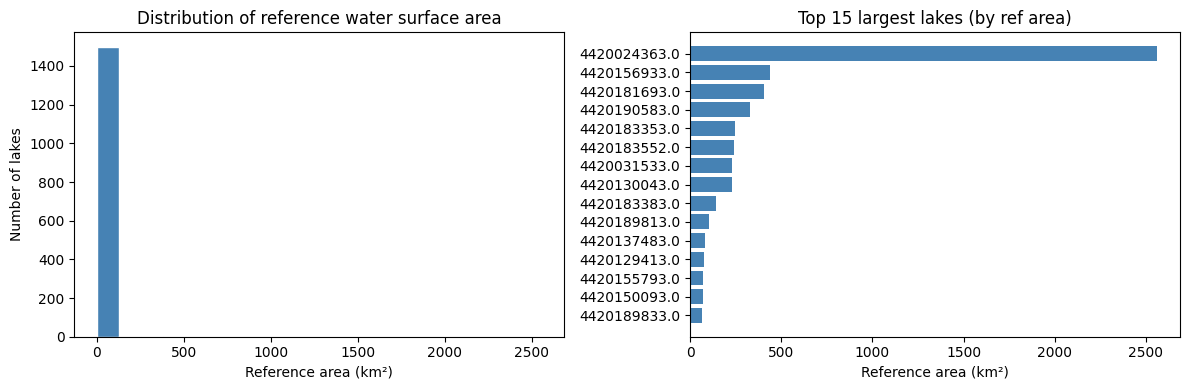

In [ ]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(pld_grit[area_col].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Reference area (km²)")
axes[0].set_ylabel("Number of lakes")
axes[0].set_title("Distribution of reference water surface area")

# Bar chart — top 15 largest lakes
top15 = area_table.head(15)
axes[1].barh(top15["lake_id"].astype(str), top15["ref_area_km2"], color="steelblue")
axes[1].invert_yaxis()
axes[1].set_xlabel("Reference area (km²)")
axes[1].set_title("Top 15 largest lakes (by ref area)")

plt.tight_layout()
plt.show()

## Filter: reservoirs with reference area > 10 km²

In [ ]:
pld_large = pld_grit[pld_grit["ref_area"] > 1].copy().reset_index(drop=True)
pld_large.index += 1

print(f"Reservoirs with ref_area > 10 km²: {len(pld_large)} / {len(pld_grit)}")
print(f"\nSummary statistics of ref_area (km²):")
print(pld_large["ref_area"].describe().round(2))

Reservoirs with ref_area > 10 km²: 252 / 1508

Summary statistics of ref_area (km²):
count     252.00
mean       27.45
std       168.57
min         1.00
25%         1.73
50%         3.45
75%         9.53
max      2559.11
Name: ref_area, dtype: float64


In [ ]:
# Full attribute table sorted by area
cols_show = ["lake_id", "names", "ref_area", "ref_wse", "lon", "lat", "storage", "sources"]
cols_show = [c for c in cols_show if c in pld_large.columns]

pld_large[cols_show].sort_values("ref_area", ascending=False).reset_index(drop=True).assign(rank=lambda df: range(1, len(df)+1)).set_index("rank")

,lake_id,names,ref_area,ref_wse,lon,lat,storage,sources
rank,,,,,,,,
1,4.420024e+09,TONLE SAP;BOENG TONLE CHHMA;STOENG VEAL DAMREI...,2559.114682,3.0640,104.071075,12.897680,NaN,Circa2015;digitize
2,4.420157e+09,None,437.832106,206.6955,102.635411,18.586083,NaN,Circa2015;digitize
3,4.420182e+09,NAM THEUN 2,403.471049,535.3990,105.116587,17.810141,NaN,Circa2015;digitize
4,4.420191e+09,None,329.472099,NaN,106.399214,13.531487,NaN,GeoDARv11
5,4.420183e+09,MEKONG,243.474233,786.7040,100.301133,22.975835,NaN,Circa2015;digitize
...,...,...,...,...,...,...,...,...
248,4.420117e+09,None,1.044000,158.0880,103.084016,14.644122,NaN,Circa2015
249,4.420127e+09,None,1.042200,257.9700,101.514438,15.508440,NaN,Circa2015
250,4.420189e+09,None,1.031400,3877.0420,96.556786,32.608894,NaN,Circa2015


## Why PLD has 1611 lakes but GRIT reaches only reference 1508?

This is because some GRIT reaches overlap two lakes at the same time. 

In [28]:
# Lakes in PLD but NOT referenced by any GRIT reach lake_id
pld_all_ids = set(pld["lake_id"].unique())
grit_ids    = set(with_lake["lake_col"].unique() if False else with_lake[lake_col].unique())

missing_ids = pld_all_ids - grit_ids
print(f"Lakes in PLD but absent from GRIT reach lake_id: {len(missing_ids)}")

pld_missing = pld[pld["lake_id"].isin(missing_ids)][
    ["lake_id", "names", "ref_area", "ref_wse", "lon", "lat", "reach_id_l", "sources"]
].sort_values("ref_area", ascending=False).reset_index(drop=True)
pld_missing.index += 1
pld_missing

Lakes in PLD but absent from GRIT reach lake_id: 103


,lake_id,names,ref_area,ref_wse,lon,lat,reach_id_l,sources
1,4.420051e+09,None,0.248400,123.8495,103.265963,15.314469,44264500063,Circa2015
2,4.420107e+09,None,0.146700,148.4150,102.878606,16.431071,None,Circa2015
3,4.420133e+09,None,0.143100,429.2725,108.249809,12.586325,None,Circa2015
4,4.420156e+09,None,0.096301,155.4010,103.245196,18.233805,None,Circa2015;digitize
5,4.420177e+09,None,0.095400,169.0130,102.840899,17.508131,None,Circa2015
...,...,...,...,...,...,...,...,...
99,4.420163e+09,None,0.012600,159.2240,103.106738,17.875438,None,Circa2015
100,4.420178e+09,None,0.011700,227.3455,101.450106,18.093149,None,Circa2015
101,4.420053e+09,None,0.010800,121.0800,104.217121,15.657159,None,Circa2015
102,4.420060e+09,None,0.010800,136.3375,103.489910,16.173727,None,Circa2015


In [32]:
pld_missing['lake_id'].values[4]

np.float64(4420176732.0)

In [29]:
# Check reach_id_l for missing lakes — if populated, the lake IS linked to a reach
# via the PLD's own reach_id_l field, just not via the GRIT reach lake_id column
has_reach_link = pld_missing["reach_id_l"].notna().sum()
print(f"Of the {len(pld_missing)} missing lakes:")
print(f"  - {has_reach_link} have a reach_id_l entry in the PLD (linked in PLD but GRIT reach doesn't carry the lake_id back)")
print(f"  - {len(pld_missing) - has_reach_link} have no reach_id_l (truly unconnected — only spatially overlapping)")
print(f"\nref_area distribution of missing lakes (km²):")
print(pld_missing["ref_area"].describe().round(3))

Of the 103 missing lakes:
  - 7 have a reach_id_l entry in the PLD (linked in PLD but GRIT reach doesn't carry the lake_id back)
  - 96 have no reach_id_l (truly unconnected — only spatially overlapping)

ref_area distribution of missing lakes (km²):
count    103.000
mean       0.036
std        0.033
min        0.011
25%        0.017
50%        0.026
75%        0.046
max        0.248
Name: ref_area, dtype: float64
